<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# The AdaGrad Optimizer

Training modern machine learning models often comes down to solving large-scale optimization problems, where we aim to minimize a loss function with respect to many parameters. The most fundamental approach to this is **Gradient Descent**, which iteratively updates parameters in the direction of the negative gradient. While simple and widely applicable, basic Gradient Descent uses a *single global learning rate* for all parameters and across all steps of training. This can be problematic, especially in high-dimensional settings or when the loss surface is ill-conditioned &mdash; some parameters may require large updates, while others need much smaller, more careful adjustments.

A key limitation of this uniform treatment is that Gradient Descent does not adapt to the *history* or *scale* of individual parameters. In practice, some parameters may consistently receive large gradients, causing unstable or oscillatory updates, while others may receive very small gradients and therefore learn extremely slowly. Ideally, we would like an optimization method that automatically adjusts the step size for each parameter based on how it behaves during training, rather than relying on a single manually tuned learning rate.

This is where **AdaGrad (Adaptive Gradient Algorithm)** comes in. AdaGrad modifies the standard update rule by scaling each parameter's learning rate according to the accumulated history of its past gradients. Parameters that have seen large or frequent gradients get smaller effective learning rates over time, while those with smaller or less frequent gradients retain relatively larger step sizes. This leads to a form of per-parameter adaptation that can be especially beneficial in settings with sparse features or highly uneven gradient distributions.

Although AdaGrad itself is not as commonly used in modern deep learning practice, it plays a crucial conceptual role in understanding more advanced optimizers such as RMSProp and Adam. In particular, AdaGrad's main limitation &mdash; its ever-decreasing learning rates due to the continual accumulation of squared gradients &mdash; motivates the development of methods that retain adaptive scaling while preventing the learning rate from shrinking too aggressively. Studying AdaGrad therefore provides valuable insight into the evolution of optimization algorithms and builds intuition for why later methods are designed the way they are.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np

from src.utils.plotting.gd import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and concepts of derivatives and partial derivatives.
* Although the notebook starts with a brief recap about basic Gradient Descient, being already familiar with this algorithm is recommended.

---

## Quick Recap: Gradient Descent

**Gradient Descent** is a fundamental iterative optimization algorithm used to find critical points of a function &mdash; most commonly minima. The core idea is simple: starting from an initial guess, the algorithm repeatedly updates the parameters by moving them in the direction opposite to the gradient (i.e., the direction of steepest increase). By taking small steps downhill, the method gradually approaches a point where the gradient is zero or close to zero, indicating a local minimum or another critical point.

In the context of training neural networks and other machine learning models, Gradient Descent is used to minimize a loss function with respect to all trainable parameters of the model. The loss function measures how well the model's predictions match the actual data, and the gradient provides information on how each parameter should be adjusted to reduce this error. By iteratively updating the parameters based on the computed gradients, the model learns patterns in the data and improves its performance over time.

In most machine learning settings, the loss function produces a single scalar value that quantifies the model's overall error, while the model itself may contain thousands or even millions of trainable parameters. As a result, training can be viewed as the problem of minimizing a multivariate function, where the loss depends on many variables simultaneously. Each parameter represents one dimension in this high-dimensional space, and Gradient Descent operates by computing partial derivatives with respect to each parameter to determine how to adjust them collectively in order to move toward a minimum of the loss function. In the following, therefore, we consider a multivariate function $f$ of the following form:

$$\large
y = f(\mathbf{x}) = f(x_1, x_2, x_3, \dots, x_d)
$$

where $y$ is the scalar output (e.g., the loss when training a neural network), and $d$ (for "dimension") is the number of inputs (parameters). Throughout this notebook we consider a multivariate function $f$ together with its derivative $g=f^\prime$ as a concrete example as defined below; we limit ourselves to only two inputs here to ease visualization, but all concepts apply to an arbitrary number of inputs.

$$
\begin{align}
\large f(x_1, x_2)\ &\large = 0.1x_1^2 + 5x_2^2\\[0.5em]
\large g(x_1, x_2)\ &\large = 0.2x_1^2 + 10x_2
\end{align}
$$

We also implement both functions as Python methods for testing all optimizer algorithms and visualizing their results.

In [2]:
def f(x1, x2):
    return 0.1*(x1**2) + 5*(x2**2)

def g(x1, x2):
    return 0.2*x1, 10*x2

Before going further, let's first have a look at the function, using the provided auxiliary method `plot_multivariate_function(f)`.

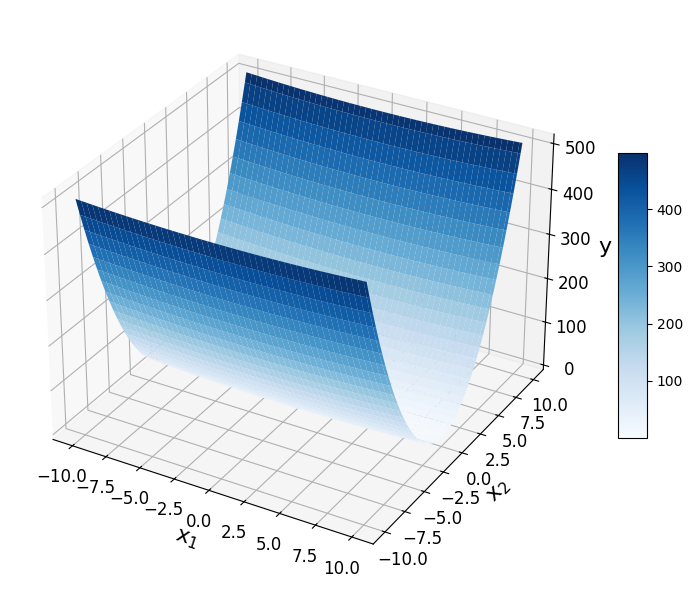

In [3]:
plot_multivariate_function(f)

Although we already know just from looking at the function $f$ that its minimum is at $x_1 = x_2 = 0$, this is not very obvious from the plot. The issues here is that function $f$, despite its simplicity, can be considered **ill-conditioned**. This means that small changes in its input or in the optimization process can lead to large and unstable changes in the output or in the path toward the minimum. In the context of optimization, this typically means that the function's curvature differs significantly across dimensions: in some directions the function changes very steeply, while in others it is relatively flat. Even for simple functions (e.g., quadratic forms), this can produce elongated, narrow valleys where the minimum lies, making it difficult for optimization algorithms to move efficiently toward the optimum.

Recall that the update step for (basic) Gradient Descent is defined as:

$$
\begin{align}
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \eta\cdot g^{(t)}
\end{align}
$$

Where $\eta$ is the learning rate, i.e., a scaling factor to (typically) scale down the current gradient. Note that we write $ g^{(t)}$ as a shorthand for $ g\left(\mathbf{x}^{(t)}\right)$ to denote the current gradient at at the $t$-th iteration to ease presentation. Implementing this formula is straightforward and done so be the method `sgd()` as shown in the code cell below.

In [4]:
def sgd(g, x0, eta, n_steps):
    # Initialize history of x values
    x, xs = x0, [x0]
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update x values based on gradient and learning rate
        x = x - eta*gradient
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Note that we keep a history of all updates. While this would not be required in practice &mdash; in general, we are only interested in the values for $\mathbf{x}$ after the last update which are hopefully close to the true minimum &mdash; we can use the history of updates for visualizing the results. To this end, let's first define the initial choice of the parameters as $x_1 = 9$ and $x_2 = -3$:

In [5]:
x0 = np.asarray([9, -3])

We can now perform Gradient Descent by executing method `sgd()`. By default, we set the learning `eta` to $0.05$ and the number of iterations `n_steps` to `100`. However, you are welcome and encouraged to vary both parameters, particularly the learning rate, to see how these changes will affect the result. That being said, the default parameters are meaningful enough to illustrate the limitations of basic Gradient Descent and motivate the advantages of momentum-based extensions to the algorithm.

In [6]:
eta, n_steps = 0.05, 100

xs_sgd = sgd(g, x0, eta, n_steps)

Right now, with `xs_sgd`, we only have the history of all parameter updates. To see the actual behavior of the Gradient Descent implementation, we provide the auxiliary method `plot_gradient_descent_2d()` to visualize the update steps in a plot. Apart from the update history `xs_sgd`, this method also receives `f` to visualize the 2d function as contour plot, and `eta` for setting the title of the plot. Just run the code cell below to generate the animated plot (note that this might take a few seconds).

In [7]:
plot_gradient_descent_2d(f, xs_sgd, eta=eta, title=f"Gradient Descent (η = {eta})")

Since we are using a single global learning rate, every dimension of the parameter vector is scaled in exactly the same way, regardless of how sensitive the loss function is to changes in that parameter. While this works reasonably well for simple and well-conditioned problems, it can become a significant limitation when dealing with more complex or ill-conditioned functions &mdash; like our example function here &mdash; where different directions in the parameter space have very different curvature.

In such cases, a single learning rate forces a difficult trade-off: if the learning rate is set too large, updates may overshoot in steep directions and cause instability; if it is set too small, progress in flat directions becomes extremely slow. Ideally, we would like the update step for each parameter to **adapt to its own scale**, taking smaller steps in directions with large gradients and larger steps where gradients are consistently small. This would lead to more balanced and efficient progress across all dimensions. This is exactly the motivation behind **AdaGrad**.

---

## The AdaGrad Algorithm

**AdaGrad (Adaptive Gradient)** is an optimization algorithm that extends basic Gradient Descent by using **parameter-specific learning rates** instead of a single global one. The basic intuition compared to Gradient Descent is that not all parameters should be treated equally during optimization. In standard Gradient Descent, a single learning rate can cause inefficient progress, especially for ill-conditioned problems where some directions require much smaller steps than others. AdaGrad addresses this by **normalizing updates based on past gradient behavior**, effectively taking smaller steps in steep directions and larger steps in flatter ones. This makes optimization more balanced and can significantly improve convergence, particularly in settings with sparse or unevenly scaled gradients. Let's see how this works in more detail.

### Definition & Implementation

The information which directions are "steep" and which are rather "flat" is directly represented by the respective values in the gradient vector: large values indicate steep directions, small values indicate flat directions. This means that, in principle, we could use the gradient to scale the learning rate for each direction. However, using only the current gradient would cause some problems as this creates a purely local, instantaneous adjustment:
* Very noisy behavior: gradients can fluctuate a lot between steps; the learning rate would jump around unpredictably
* No memory: the optimizer forgets whether a parameter has been consistently large or small in the past
* Overreaction to spikes: a single large gradient could drastically shrink the step size for that update, even if it is just noise

To make this more tangible in many real-world Natural Language Processing tasks, some features &mdash; typically tokens or words &mdash; appear in 99% of samples, while others appear in 0.01%. If we would use the current gradient, the learning rate for a rare token would only be "high" during the exact moment that word appears.   

Thus, to avoid this often unstable and inconsistent behavior, AdaGrad captures the information about gradients as the sum of squared gradients. Mathematically, AdaGrad updates the sum of squared gradient using the following update rule:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \mathbf{v}^{(t)} + \left[ g^{(t)} \right]^2
\end{align}
$$

In the case of our NLP example, by using the sum, AdaGrad "remembers" that the rare token has had very little total update volume over the last $t$ steps. This keeps its learning rate high for a long duration, giving the model a better chance to learn from that rare information whenever it does crop up. In short AdaGrad effectively uses the average activity of that parameter over time. The sum acts as a low-pass filter, smoothing out the noise and ensuring the learning rate changes gradually rather than sporadically. 

While this motivates computing the sum, there are also concrete reasons to compute the square of the gradients:
* Squaring ensures that every update is treated as a positive contribution to the "total movement" history, regardless of direction.
* Squaring gives more weight to large gradients than small ones; in AdaGrad, we want to penalize large, volatile updates more aggressively.
* Squaring, compared to the absolute function, yields a smooth and differentiable function; in optimization, we prefer functions with smooth derivatives because they behave predictably.
* Squaring the gradient naturally relates to *variance estimation* (like in statistics) and second-order methods (curvature); $\mathbb{E}\left[g^2\right]$ is a proxy for the second moment, plus diagonal second-order methods (like approximations of the Hessian) also depend on squared quantities.

In fact, the last bullet point is one of the most fundamental reasons for using the squared gradients to compute the sum. A deeper theoretical discussion is, however, beyond the scope of this notebook.

AdaGrad now uses this sum of squared gradients (i.e., the history of past gradients) to scale the learning rate using the following formula:

$$
\begin{align}
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \frac{\eta}{\sqrt{\mathbf{v}^{(t)} + \epsilon}}\odot g^{(t)}
\end{align}
$$

where $\odot$ is the Hadamard product, i.e., the elementwise product. The small constant $\epsilon$ in the scaling factor avoids division by $0$ in case that one more entries in $\mathbf{v}^{t}$ are $0$. We take the square root since $\mathbf{v}^{t}$ is the sum of squared gradients, but we want to scale with respect to the "unsquared" magnitudes of the gradients.

In terms of implementing AdaGrad, compared to basic Gradient Descent, we only need to (a) keep track of the sum of squared gradients and (b) use this sum to scale the learning rate $\eta$. The method `adagrad()` in the code cell below incorporates these two additions to the initial Gradient Descent algorithm seen before.

In [8]:
def adagrad(g, x0, eta, n_steps, epsilon=1e-8):
    # Initialize history of x values
    x, xs = x0, [x0]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update sum of squared gradients
        v = v + gradient**2
        # Update x values based on gradient and learning rate
        x = x - (eta*gradient / (np.sqrt(v + epsilon)))
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's find the minimum for our example function $f$ using the `adagrad()` method. We have to keep in mind, however, that in AdaGrad, the learning rate adjustment is fundamentally different from basic Gradient Descent because it moves from a static global value to a dynamic per-parameter value. Because the denominator (the sum of squared gradients) grows from the very first step, the effective learning rate scales down instantly. 

In AdaGrad, we can (and often should) start with a larger initial learning rate, one or even two orders of magnitude larger compared to basic Gradient Descent. In the code cell below, we therefore set $\eta=0.5$ by default, i.e., $10$x the learning rate we used before when using the method `sgd()` to find the minimum.

In [9]:
eta, n_steps = 0.5, 100

xs_adagrad = adagrad(g, x0, eta, n_steps)

As before, with `xs_adagrad`, we now have the parameter values for each iteration (i.e., update step) which can be plotted using the auxiliary method `plot_gradient_descent_2d()`.

In [10]:
plot_gradient_descent_2d(f, xs_adagrad, eta=eta, title=f"AdaGrad (η = {eta})")

As the plot shows, AdaGrad transitions toward a heterogeneous update trend where each parameter follows its own unique trajectory &mdash; compared with the plot for Gradient Descent which exhibits update trend biased towards steep directions. Parameters associated with frequently occurring features experience an aggressive, early "braking" effect as their squared gradient sums grow rapidly, preventing them from dominating the optimization process. Meanwhile, parameters for rare features maintain a relatively higher effective learning rate for much longer. This results in an automated balancing act where the model "invests" more movement into the dimensions that have been least explored, leading to a more nuanced and efficient convergence on datasets with uneven feature distributions.

### Discussion

AdaGrad provides as simple but quite intuitive extension to the basic Gradient Descent algorithm by enabling parameter-specific learning rates based on the information about past gradients. In practice, this often comes with many benefits, more specifically:
* *Handling Sparse Data:* In learning tasks where most features are zero most of the time (e.g., in NLP or recommender systems), AdaGrad ensures that rare features get a large enough update to be learned, while common features do not overwhelm the model.
* *Reduced Manual Tuning:* Because AdaGrad scales the learning rate for each parameter automatically, we do not have to spend as much time tweaking the learning rate or designing complex decay schedules.
* *Stability in steep landscapes:* By penalizing dimensions with large gradients, AdaGrad naturally prevents the "exploding gradient" problem and dampens oscillations in steep areas of the loss surface.
* *Better convergence on convex problems:* For many convex optimization tasks, AdaGrad has theoretical guarantees for convergence that are superior to standard SGD.


The main **downside of AdaGrad** is that its effective learning rate **monotonically decreases over time**. This happens because it accumulates the sum of all past squared gradients, which continuously grows as training progresses. Since each parameter update is scaled by the inverse of this accumulated value, the step sizes become smaller and smaller, regardless of whether the optimizer is close to a minimum or still far away. In the early stages, this behavior can be beneficial, as it stabilizes learning and prevents overly large updates. However, over time the learning rates can shrink so much that parameter updates become negligibly small.

In practice, this leads to a major problem: **training can stall prematurely**. Even if the model has not yet reached a good solution, AdaGrad may stop making meaningful progress because its updates have become too tiny. This is particularly problematic in complex, non-convex optimization landscapes such as those encountered in deep learning, where continued exploration and adjustment are necessary throughout training. Additionally, because AdaGrad never "forgets" past gradients, even early noisy updates permanently reduce future learning rates, making it difficult for the optimizer to adapt if the optimization dynamics change over time.

To address this limitation, more advanced optimizers modify how gradient history is accumulated. **RMSProp** replaces the cumulative sum with an exponentially weighted moving average of squared gradients, allowing the optimizer to “forget” older information and maintain a more stable, non-vanishing learning rate. **Adam** builds on this idea by combining RMSProp-style adaptive scaling with momentum, enabling both smoother updates and continued progress throughout training. These methods retain AdaGrad's key insight &mdash; per-parameter adaptive learning rates, while avoiding the problem of ever-shrinking step sizes.

---

## Summary

In this notebook, we explored **AdaGrad (Adaptive Gradient Algorithm)** as an extension of basic Gradient Descent, motivated by the need to overcome the limitations of using a single global learning rate for all parameters. While standard Gradient Descent applies uniform updates regardless of a parameter's behavior, AdaGrad introduces a simple but powerful idea: adapt the learning rate individually for each parameter based on its past gradients. By accumulating the squared gradients over time, AdaGrad scales updates such that frequently updated parameters receive smaller steps, while infrequent ones retain relatively larger learning rates.

The core intuition behind AdaGrad is to incorporate **historical gradient information** into the optimization process. Instead of reacting only to the current gradient, AdaGrad builds a memory of past updates, effectively normalizing parameter updates according to how "active" each parameter has been. This leads to more stable and tailored updates, particularly in high-dimensional or sparse settings, where different parameters may require very different learning dynamics. As a result, AdaGrad often performs well without extensive manual tuning of the learning rate.

We also examined the main advantages of AdaGrad, including its ability to handle sparse data efficiently, its reduced sensitivity to the initial learning rate, and its simplicity of implementation. However, these benefits come with an important drawback: because AdaGrad continuously accumulates squared gradients, its effective learning rates **shrink monotonically over time**. This can cause updates to become vanishingly small, leading to premature convergence or stalled training, especially in complex, non-convex problems such as deep neural networks.

This key limitation motivates the development of more advanced optimizers such as RMSProp and Adam. These methods retain AdaGrad's central idea of adaptive, per-parameter learning rates but address its shortcomings by introducing mechanisms to **limit or forget past gradient information**, preventing the learning rate from decaying too aggressively. Understanding AdaGrad therefore provides an essential foundation for appreciating how modern optimization algorithms are designed and why they are more effective in practice.